# Bearing anomaly detection — DCASE-style (1D waveform U-Net autoencoder)

This notebook trains an **unsupervised** anomaly detector on **normal-only** bearing audio from `eval_data_bearing_train.zip`, scores **unlabeled** clips from `eval_data_bearing_test.zip`, and (optionally) measures **AUC / pAUC** on labeled **development** test audio from `dev_bearing.zip` (cross-section generalization: train sections 03–05, test sections 00–02).

**Always run section 0 first** (installs dependencies and sets `PROJECT_ROOT`). Defaults are now set for a **full training run** (all training files, multi-epoch). For quick checks, switch `TRAIN_FILE_CAP`, `NUM_EPOCHS`, and `FORCE_CPU` in section 2.

Code lives in the `1DUnet/` module folder (mirrors the structure of `bearing_asd/` used by the 2D notebook).

## 0. Environment bootstrap (Google Colab + local)

- Uncomment `os.chdir(...)` if Colab’s working directory is not the project folder.
- Installs `requirements.txt` via `pip`.
- Adds `1DUnet/` to `sys.path` so notebook imports use the modular 1D pipeline.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import sys
import subprocess
from pathlib import Path

# --- Google Colab: uncomment if cwd is not your project root ---
os.chdir("/content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound")

PROJECT_ROOT = Path.cwd().resolve()
ONE_D_DIR = PROJECT_ROOT / "1DUnet"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(ONE_D_DIR) not in sys.path:
    sys.path.insert(0, str(ONE_D_DIR))

req = PROJECT_ROOT / "requirements.txt"
if req.is_file():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req)], check=False)
else:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "librosa",
            "soundfile",
            "numpy",
            "pandas",
            "matplotlib",
            "scikit-learn",
            "tqdm",
            "torchinfo",
        ],
        check=False,
    )

import torch

print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), end="")
if torch.cuda.is_available():
    print(f" | {torch.cuda.get_device_name(0)}")
else:
    print()

try:
    from IPython import get_ipython

    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("PROJECT_ROOT =", PROJECT_ROOT)
print("ONE_D_DIR =", ONE_D_DIR)

torch: 2.10.0+cu128 | CUDA: True | Tesla T4
PROJECT_ROOT = /content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound
ONE_D_DIR = /content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/1DUnet


## 1. Dataset and problem (summary)

See `1DUnet/data_description_1d.py` for the full narrative and split usage.

In [4]:
from IPython.display import Markdown, display

from data_description_1d import get_dataset_overview_markdown

display(Markdown(get_dataset_overview_markdown()))

## What this data is

The archives follow **DCASE 2022 Challenge Task 2** style bearing audio:

- **Modality**: single-channel **waveform audio**, around **10s** per clip.
- **Machine type here**: **bearing**.
- **Training split used here**: `eval_data_bearing_train.zip` -> `bearing/train` (sections 03-05, normal clips).
- **Unlabeled scoring split**: `eval_data_bearing_test.zip` -> `bearing/test`.
- **Optional labeled metrics**: `dev_bearing.zip` -> dev `bearing/test` (sections 00-02 with normal/anomaly labels in filenames).

---

## Problem statement

Train an **unsupervised 1D waveform U-Net autoencoder** on normal clips only.
At inference, compute per-clip reconstruction MSE (higher means more anomalous).

## 2. Setup — paths, extract archives, counts

This section verifies exactly which folders are used:

- Train normal clips: `data/dcase_bearing_eval/bearing/train/`
- Unlabeled eval clips: `data/dcase_bearing_eval/bearing/test/`
- Optional labeled dev clips: `data/dcase_bearing_dev/bearing/test/`

In [5]:
from __future__ import annotations

import sys
import torch
from pathlib import Path

from IPython.display import display

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd().resolve()

ONE_D_DIR = PROJECT_ROOT / "1DUnet"
if str(ONE_D_DIR) not in sys.path:
    sys.path.insert(0, str(ONE_D_DIR))

from config_1d import WaveformConfig, TrainConfig, default_paths
from data_loading_1d import (
    describe_attributes_csv,
    ensure_dev_data,
    ensure_eval_data,
    list_wavs,
    load_dev_test_manifest,
    make_train_loaders,
)

paths = default_paths(PROJECT_ROOT)
feat = WaveformConfig(sample_rate=16000, fixed_length=65536)

# Full-run defaults (edit for quick smoke tests):
NUM_EPOCHS = 20
FORCE_CPU = False
_bs = 32 if torch.cuda.is_available() else 16

train_cfg = TrainConfig(
    batch_size=_bs,
    epochs=NUM_EPOCHS,
    learning_rate=1e-3,
    val_fraction=0.1,
    num_workers=0,
    seed=42,
    device="cpu" if FORCE_CPU else ("cuda" if torch.cuda.is_available() else "cpu"),
)

# Use all available normal training files by default.
TRAIN_FILE_CAP = None

bearing_root = ensure_eval_data(paths)
train_wavs = list_wavs(bearing_root / "train")
if TRAIN_FILE_CAP is not None:
    train_wavs = train_wavs[: int(TRAIN_FILE_CAP)]

eval_test_wavs = list_wavs(bearing_root / "test")
print("Bearing root:", bearing_root)
print("Train wavs (normal only):", len(train_wavs))
print("Eval test wavs (unlabeled):", len(eval_test_wavs))

print("\nData folders used by this 1D model:")
print("- train:", bearing_root / "train")
print("- eval test:", bearing_root / "test")

dev_root = ensure_dev_data(paths)
if dev_root is not None:
    dev_manifest = load_dev_test_manifest(dev_root / "test")
    print("- dev test (labeled):", dev_root / "test")
    print("Dev test wavs (labeled):", len(dev_manifest))
else:
    dev_manifest = None
    print("dev_bearing.zip not found — skip labeled evaluation")

attr03 = bearing_root / "attributes_03.csv"
if attr03.is_file():
    display(describe_attributes_csv(attr03))

Bearing root: /content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/data/dcase_bearing_eval/bearing
Train wavs (normal only): 3000
Eval test wavs (unlabeled): 600

Data folders used by this 1D model:
- train: /content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/data/dcase_bearing_eval/bearing/train
- eval test: /content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/data/dcase_bearing_eval/bearing/test
- dev test (labeled): /content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/data/dcase_bearing_dev/bearing/test
Dev test wavs (labeled): 600


,file_name,d1p,d1v
0,bearing/train/section_03_source_train_normal_0...,vel,5
1,bearing/train/section_03_source_train_normal_0...,vel,17
2,bearing/train/section_03_source_train_normal_0...,vel,5
3,bearing/train/section_03_source_train_normal_0...,vel,13
4,bearing/train/section_03_source_train_normal_0...,vel,13


## 3. Data visualization

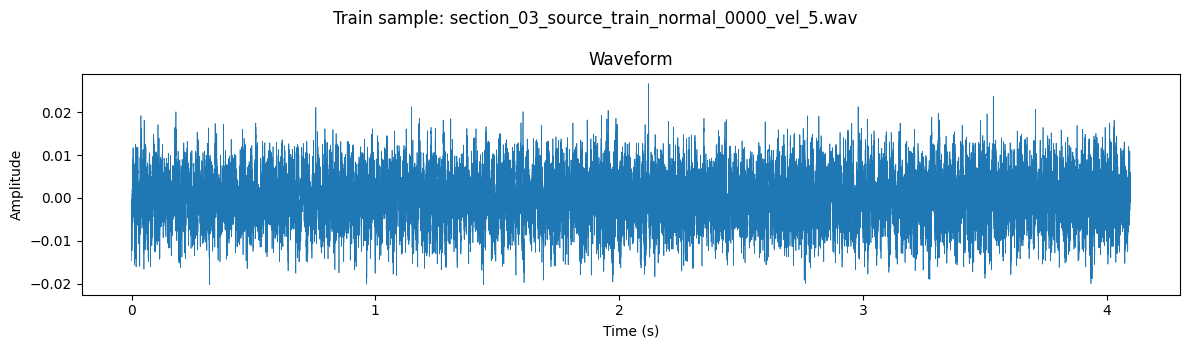

In [6]:
import matplotlib.pyplot as plt
from data_visualisation_1d import plot_waveform

sample = train_wavs[0]
fig = plot_waveform(sample, feat, title=f"Train sample: {sample.name}")
plt.show()

## 4. Model — 1D waveform U-Net autoencoder + summary

In [7]:
from model_unet_1d import build_model, model_summary_text
from model_summary_1d import print_model_summary

device = torch.device(train_cfg.device)
model = build_model(in_channels=1, base_channels=32).to(device)

dummy = torch.zeros(1, 1, feat.fixed_length)
print(model_summary_text(model, dummy.to(device)))
print_model_summary(model, input_shape=tuple(dummy.shape), device=str(device))

UNet1DAutoencoder(
  (enc1): ConvBlock1D(
    (net): Sequential(
      (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock1D(
    (net): Sequential(
      (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5

## 5. DataLoaders — train / validation split (normal only)

In [8]:
train_loader, val_loader = make_train_loaders(
    train_wavs,
    feat,
    batch_size=train_cfg.batch_size,
    val_fraction=train_cfg.val_fraction,
    seed=train_cfg.seed,
    num_workers=train_cfg.num_workers,
)
len(train_loader.dataset), len(val_loader.dataset) if val_loader else 0

(2700, 300)

## 6. Training (reconstruction MSE)

Defaults are configured for a full run (`NUM_EPOCHS=20`, `TRAIN_FILE_CAP=None`). For fast checks, set `NUM_EPOCHS=1`, `TRAIN_FILE_CAP=128`, and `FORCE_CPU=True` in section 2.

In [9]:
from training_1d import fit

ckpt = PROJECT_ROOT / "results" / "bearing_unet_waveform_1d.pt"
result = fit(
    model,
    train_loader,
    val_loader,
    epochs=train_cfg.epochs,
    lr=train_cfg.learning_rate,
    device=device,
    checkpoint_path=ckpt,
)
result["history"], result["checkpoint"]

epochs:   0%|          | 0/20 [00:00<?, ?it/s]

({'train_loss': [0.04210724367760122,
   0.0021320093754265044,
   0.0016226384971566774,
   0.0011699413561641618,
   0.0009638582856428844,
   0.000848782975571575,
   0.0007607238558638427,
   0.0007063346760157772,
   0.0005839225651558351,
   0.0005867543279331316,
   0.0005229458861328938,
   0.0004736045686769541,
   0.0004028078336354897,
   0.00035627626867844135,
   0.0003907387112094848,
   0.00032631151955919685,
   0.00028823045772258883,
   0.0002471631703277429,
   0.00030137684213480466,
   0.00025677372843751475],
  'val_loss': [0.004141834812859694,
   0.0017255711865921816,
   0.0014267098903656007,
   0.0010190274938941001,
   0.0007255957089364528,
   0.0008927456010133028,
   0.0006452599990492066,
   0.00043273771996609866,
   0.0003739899955689907,
   0.0003722990894069274,
   0.00033034172918026646,
   0.00030708369992983836,
   0.000251105735078454,
   0.00034556936472654345,
   0.0013009303094198307,
   0.0002030796759451429,
   0.000252177045137311,
   0.000

## 7. Evaluation — labeled dev test (cross-section)

Train sections **03–05** vs. dev test **00–02** is a strict generalization check.

In [10]:
from data_loading_1d import make_dev_manifest_loader
from evaluation_1d import (
    anomaly_scores,
    evaluate_dev_sections,
    evaluation_report_markdown,
    overall_metrics,
    load_model_weights,
)

if dev_manifest is not None and len(dev_manifest):
    dev_loader = make_dev_manifest_loader(
        dev_manifest,
        feat,
        batch_size=train_cfg.batch_size,
        num_workers=train_cfg.num_workers,
    )
    scores_dev = anomaly_scores(model, dev_loader, device)
    idx = dev_manifest.set_index("name")
    scores_dev["section"] = [int(idx.loc[n, "section"]) for n in scores_dev["name"]]
    scores_dev["label"] = [int(idx.loc[n, "label"]) for n in scores_dev["name"]]
    print("Overall:", overall_metrics(scores_dev))
    display(evaluate_dev_sections(scores_dev))
    print(evaluation_report_markdown(scores_dev))
else:
    print("No dev manifest; skipping AUC.")

Overall: {'auc': 0.5376666666666667, 'pauc_0.1': 0.10877777777777779}


,section,auc,pauc_0.1,n
0,0,0.6081,0.124,200
1,1,0.6778,0.182,200
2,2,0.2659,0.046,200


### Evaluation metrics (development test)

- **AUC (overall):** 0.5377
- **pAUC @ FPR<=0.1 (overall):** 0.1088
- **N clips:** 600

**Per section (bearing dev 00-02):**

 section    auc  pauc_0.1   n
       0 0.6081     0.124 200
       1 0.6778     0.182 200
       2 0.2659     0.046 200


## 8. Explainability (best checkpoint)

After training, `fit` reloads the **lowest validation loss** weights into `model`. You can also call `load_model_weights(model, ckpt, device)` to load `results/bearing_unet_waveform_1d.pt` explicitly.

Plots show input waveform, reconstruction, squared error over time, and input-gradient saliency for clip MSE.

/content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/data/dcase_bearing_dev/bearing/test/section_00_source_test_normal_0000_vel_10.wav clip MSE score: 0.00020450272131711245


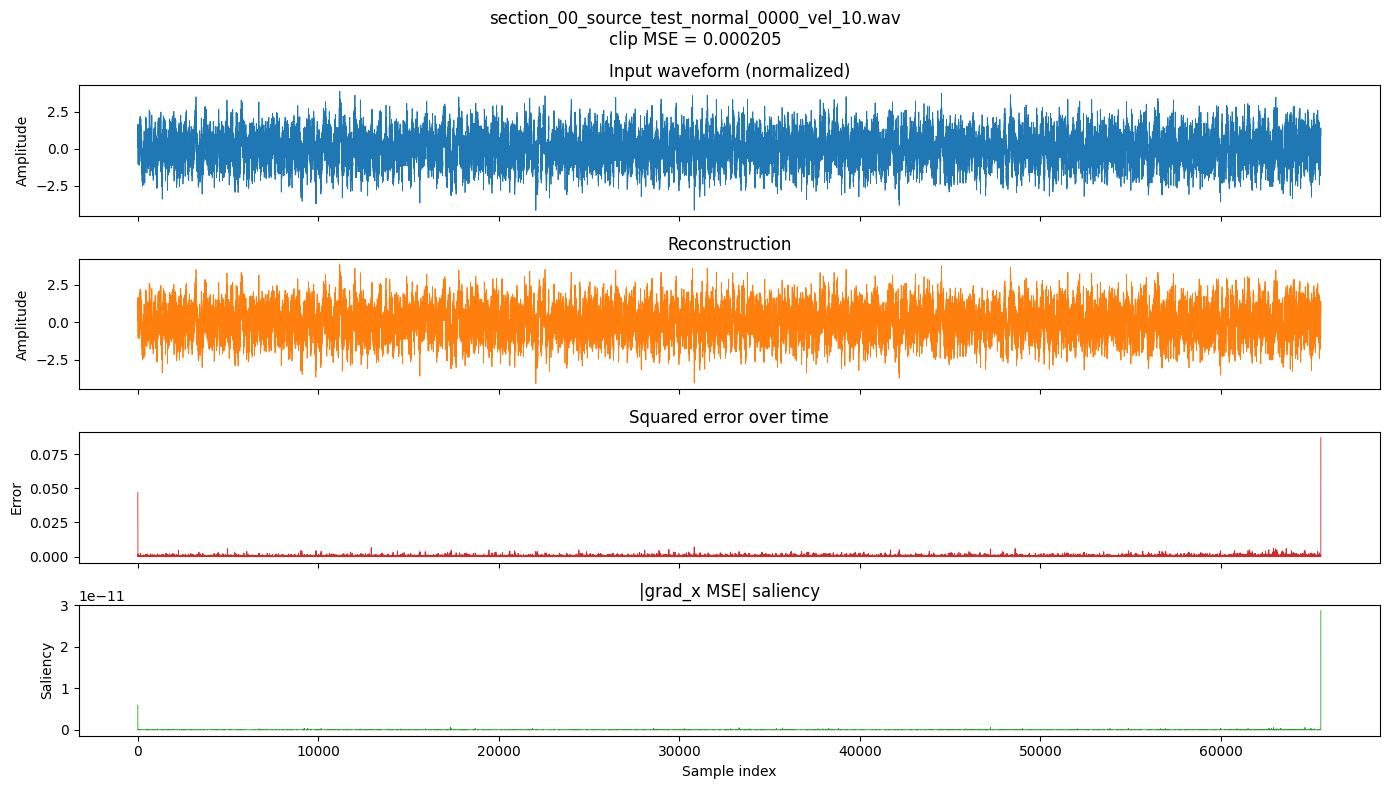

/content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/data/dcase_bearing_dev/bearing/test/section_00_source_test_anomaly_0000_vel_6.wav clip MSE score: 0.0002333755837753415


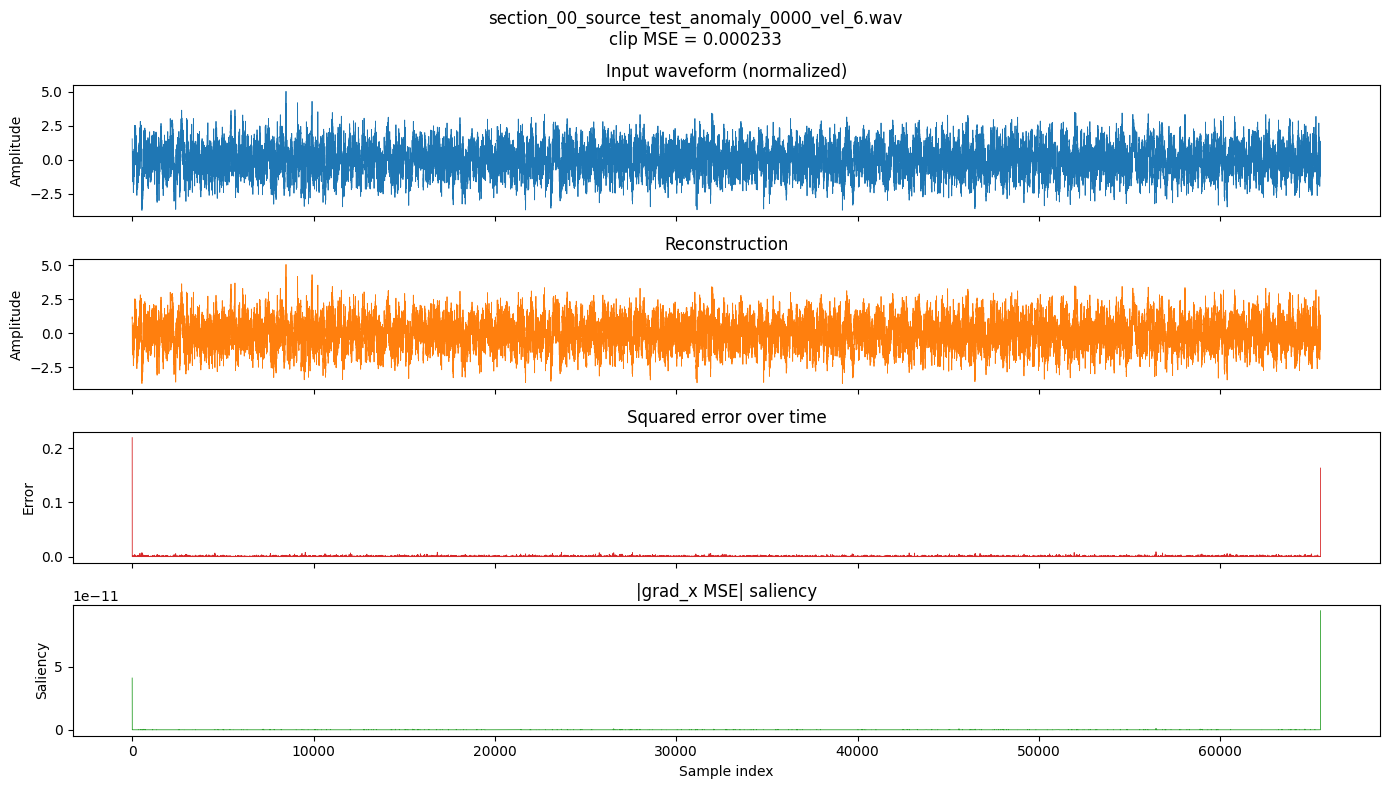

In [11]:
import matplotlib.pyplot as plt
from explainability_1d import explain_wav_file

# Optional explicit reload:
# load_model_weights(model, ckpt, device)

if dev_root is not None:
    test_dir = dev_root / "test"
    sample_normal = next(test_dir.glob("*_test_normal_*.wav"), None)
    sample_anom = next(test_dir.glob("*_test_anomaly_*.wav"), None)
    for p in [sample_normal, sample_anom]:
        if p is None:
            continue
        out = explain_wav_file(model, p, feat, device, with_saliency=True)
        print(out["path"], "clip MSE score:", out["mse"])
        plt.show()
else:
    print("No dev data; skip explainability demo.")

## 9. Evaluation — official-style unlabeled eval clips

Scores are written to `results/anomaly_scores_bearing_eval_test_1dunet.csv` (filename, score). This is separate from the 2D model output file.

In [12]:
from data_loading_1d import make_simple_loader
from evaluation_1d import anomaly_scores, save_scores_csv

eval_loader = make_simple_loader(
    eval_test_wavs,
    feat,
    batch_size=train_cfg.batch_size,
    num_workers=train_cfg.num_workers,
    shuffle=False,
)
scores_eval = anomaly_scores(model, eval_loader, device)
out_csv = PROJECT_ROOT / "results" / "anomaly_scores_bearing_eval_test_1dunet.csv"
save_scores_csv(scores_eval, out_csv)
scores_eval.head(), out_csv

(                                                path                 name  \
 0  /content/drive/MyDrive/Colab Notebooks/Unsuper...  section_03_0000.wav   
 1  /content/drive/MyDrive/Colab Notebooks/Unsuper...  section_03_0001.wav   
 2  /content/drive/MyDrive/Colab Notebooks/Unsuper...  section_03_0002.wav   
 3  /content/drive/MyDrive/Colab Notebooks/Unsuper...  section_03_0003.wav   
 4  /content/drive/MyDrive/Colab Notebooks/Unsuper...  section_03_0004.wav   
 
       score  
 0  0.000278  
 1  0.000173  
 2  0.000148  
 3  0.000229  
 4  0.000178  ,
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/results/anomaly_scores_bearing_eval_test_1dunet.csv'))

## 10. 1D vs 2D comparison (same dev test split)

This section compares your trained 1D waveform U-Net and 2D mel U-Net on the same labeled dev test set (if available), and also shows checkpoint validation losses.

In [13]:
import pandas as pd
import torch
from IPython.display import display

comparison_rows = []

# 1D checkpoint stats
ckpt_1d = PROJECT_ROOT / "results" / "bearing_unet_waveform_1d.pt"
ckpt_2d = PROJECT_ROOT / "results" / "bearing_unet_mel.pt"

val_loss_1d = None
val_loss_2d = None
if ckpt_1d.is_file():
    state_1d = torch.load(ckpt_1d, map_location="cpu")
    val_loss_1d = state_1d.get("val_loss")
if ckpt_2d.is_file():
    state_2d = torch.load(ckpt_2d, map_location="cpu")
    val_loss_2d = state_2d.get("val_loss")

# 1D dev metrics
if dev_manifest is not None and len(dev_manifest):
    from data_loading_1d import make_dev_manifest_loader as make_dev_loader_1d
    from evaluation_1d import anomaly_scores as anomaly_scores_1d, overall_metrics as overall_metrics_1d

    dev_loader_1d = make_dev_loader_1d(
        dev_manifest,
        feat,
        batch_size=train_cfg.batch_size,
        num_workers=train_cfg.num_workers,
    )
    scores_1d = anomaly_scores_1d(model, dev_loader_1d, device)
    idx_1d = dev_manifest.set_index("name")
    scores_1d["label"] = [int(idx_1d.loc[n, "label"]) for n in scores_1d["name"]]
    m1d = overall_metrics_1d(scores_1d)
else:
    m1d = {"auc": float("nan"), "pauc_0.1": float("nan")}

comparison_rows.append(
    {
        "model": "1D waveform U-Net",
        "checkpoint": str(ckpt_1d),
        "checkpoint_val_loss": val_loss_1d,
        "dev_auc": m1d["auc"],
        "dev_pauc_0.1": m1d["pauc_0.1"],
    }
)

# 2D dev metrics (same dev split)
try:
    from bearing_asd.config import AudioFeatureConfig
    from bearing_asd.data_loading import make_dev_manifest_loader as make_dev_loader_2d
    from bearing_asd.model_unet import build_model as build_model_2d
    from bearing_asd.evaluation import anomaly_scores as anomaly_scores_2d, overall_metrics as overall_metrics_2d, load_model_weights as load_model_weights_2d

    if dev_manifest is not None and len(dev_manifest) and ckpt_2d.is_file():
        feat_2d = AudioFeatureConfig()
        model_2d = build_model_2d(in_channels=1, base_channels=32)
        device_2d = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        load_model_weights_2d(model_2d, ckpt_2d, device_2d)

        dev_loader_2d = make_dev_loader_2d(
            dev_manifest,
            feat_2d,
            batch_size=train_cfg.batch_size,
            num_workers=train_cfg.num_workers,
        )
        scores_2d = anomaly_scores_2d(model_2d, dev_loader_2d, device_2d)
        idx_2d = dev_manifest.set_index("name")
        scores_2d["label"] = [int(idx_2d.loc[n, "label"]) for n in scores_2d["name"]]
        m2d = overall_metrics_2d(scores_2d)
    else:
        m2d = {"auc": float("nan"), "pauc_0.1": float("nan")}
except Exception as e:
    print("2D comparison skipped:", e)
    m2d = {"auc": float("nan"), "pauc_0.1": float("nan")}

comparison_rows.append(
    {
        "model": "2D mel U-Net",
        "checkpoint": str(ckpt_2d),
        "checkpoint_val_loss": val_loss_2d,
        "dev_auc": m2d["auc"],
        "dev_pauc_0.1": m2d["pauc_0.1"],
    }
)

comparison_df = pd.DataFrame(comparison_rows)
print("Comparison on same dev split (00-02), if files are available:")
display(comparison_df)

Comparison on same dev split (00-02), if files are available:


,model,checkpoint,checkpoint_val_loss,dev_auc,dev_pauc_0.1
0,1D waveform U-Net,/content/drive/MyDrive/Colab Notebooks/Unsuper...,0.000194,0.537667,0.108778
1,2D mel U-Net,/content/drive/MyDrive/Colab Notebooks/Unsuper...,0.001936,0.617489,0.074111


## 11. Anomaly Score Distribution Comparison

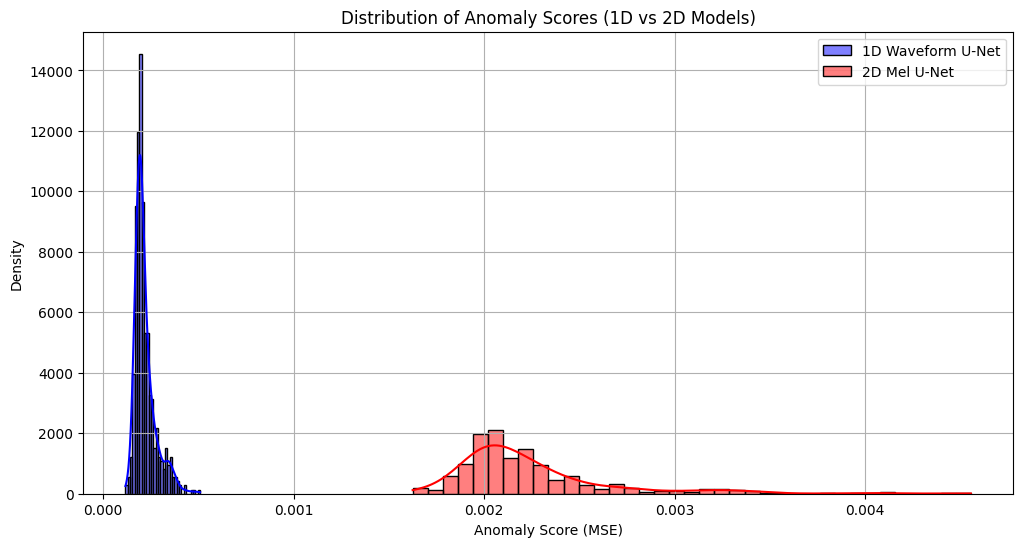

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the scores_1d and scores_2d DataFrames exist and contain a 'score' column
if 'scores_1d' in locals() and 'scores_2d' in locals() and 'score' in scores_1d.columns and 'score' in scores_2d.columns:
    plt.figure(figsize=(12, 6))
    sns.histplot(scores_1d['score'], color='blue', label='1D Waveform U-Net', kde=True, stat='density', alpha=0.5)
    sns.histplot(scores_2d['score'], color='red', label='2D Mel U-Net', kde=True, stat='density', alpha=0.5)
    plt.title('Distribution of Anomaly Scores (1D vs 2D Models)')
    plt.xlabel('Anomaly Score (MSE)')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Anomaly scores (scores_1d or scores_2d) not available. Please run previous evaluation cells.")